In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/project_1/customer_reviews_cleaned.csv')

In [ ]:
df.shape

(30840, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30840 entries, 0 to 30839
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   customer_id            30840 non-null  int64 
 1   product_id             30840 non-null  object
 2   product_title          30840 non-null  object
 3   star_rating            30840 non-null  int64 
 4   helpful_votes          30840 non-null  int64 
 5   total_votes            30840 non-null  int64 
 6   verified_purchase      30840 non-null  object
 7   review_date            30840 non-null  object
 8   sentiment              30840 non-null  int64 
 9   review_body_clean      30812 non-null  object
 10  review_headline_clean  30825 non-null  object
 11  year                   30840 non-null  int64 
 12  month                  30840 non-null  int64 
 13  month_name             30840 non-null  object
 14  seller_id              30840 non-null  object
dtypes: int64(7), object

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [ ]:
import re

def clean_review(text):
    if pd.isna(text):
        return text

    # Fix 'wordbr nextword' → 'word. next word'
    text = re.sub(r'(\w)br\s+', r'\1. ', text)

    # Remove any remaining standalone 'br'
    text = re.sub(r'\bbr\b', '', text)

    # Fix multiple spaces
    text = re.sub(r' {2,}', ' ', text)

    return text.strip()

df['review_body_clean'] = df['review_body_clean'].apply(clean_review)
df['review_headline_clean'] = df['review_headline_clean'].apply(clean_review)

In [ ]:
cols = [
    'customer_id', 'product_id', 'seller_id',   # ← side by side
    'product_title', 'star_rating', 'helpful_votes', 'total_votes',
    'verified_purchase', 'review_date', 'sentiment',
    'review_body_clean', 'review_headline_clean',
    'year', 'month', 'month_name'
]

df = df[cols]

In [ ]:
df.head()

,customer_id,product_id,seller_id,product_title,star_rating,helpful_votes,total_votes,verified_purchase,review_date,sentiment,review_body_clean,review_headline_clean,year,month,month_name
0,11555559,B00IKPX4GY,seller_2,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",5,0,0,Y,2015-08-31,1,great love it,five stars,2015,8,Aug
1,31469372,B00IKPYKWG,seller_3,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",3,0,0,N,2015-08-31,0,lots of ads. slow processing speed. occasional...,lots of ads slow processing speed occasionally...,2015,8,Aug
2,26843895,B00IKPW0UA,seller_1,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",5,0,0,Y,2015-08-31,1,excellent unit the versatility of this tablet ...,well thought out device,2015,8,Aug
3,19844868,B00LCHSHMS,seller_16,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",4,0,0,N,2015-08-31,1,i bought this on amazon prime so i ended up bu...,not all appsgames we were looking forward to u...,2015,8,Aug
4,1189852,B00IKPZ5V6,seller_4,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",5,0,0,Y,2015-08-31,1,all amazon products continue to meet my expect...,five stars,2015,8,Aug


In [ ]:
#Creating Sentiment Labels
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment_label"] = df["star_rating"].apply(sentiment_label)

In [ ]:
sentiment_summary = (
    df['sentiment_label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

sentiment_summary.columns = ['sentiment_label', 'Percentage']

print(sentiment_summary)

  sentiment_label  Percentage
0        Positive       83.54
1        Negative        9.28
2         Neutral        7.19


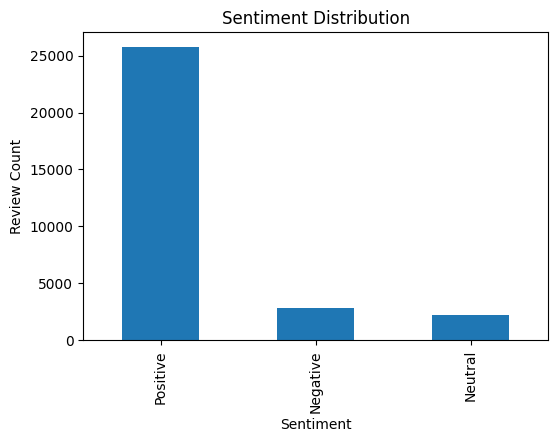

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Review Count')

plt.show()

Customer sentiment is overwhelmingly positive, with over 83% of reviews classified as positive. Negative sentiment accounts for only 16%, indicating strong overall customer satisfaction.

##Sentiment Relate To Ratings

In [ ]:
rating_sentiment = pd.crosstab(
    df['star_rating'],
    df['sentiment_label']
)

print(rating_sentiment)

sentiment_label  Negative  Neutral  Positive
star_rating                                 
1                    1707        0         0
2                    1154        0         0
3                       0     2216         0
4                       0        0      5746
5                       0        0     20017


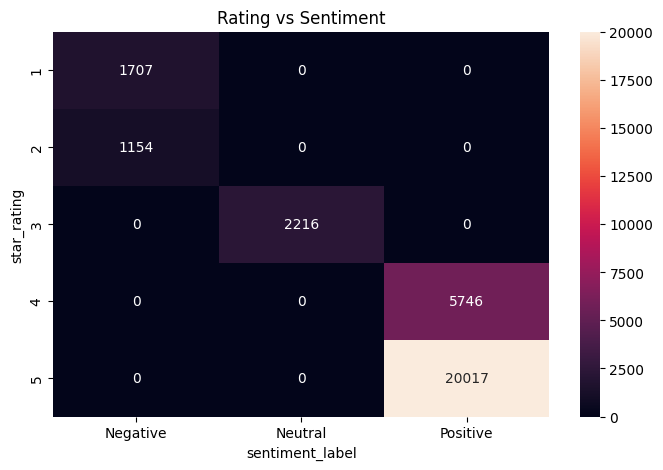

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

rating_sentiment = pd.crosstab(
    df['star_rating'],
    df['sentiment_label']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    rating_sentiment,
    annot=True,
    fmt='d'
)

plt.title('Rating vs Sentiment')
plt.show()

* Rating-to-sentiment mapping is clean with no misclassifications;
* majority of reviews are Positive (5-star dominates with 20,017).

In [ ]:
seller_positive = (
    df[df['sentiment_label'] == 'Positive']
    .groupby('seller_id')
    .size()
    .reset_index(name='Positive Reviews')
)

seller_positive = seller_positive.sort_values(
    by='Positive Reviews',
    ascending=False
).head(5)

print(seller_positive)

    seller_id  Positive Reviews
14   seller_3              9864
0    seller_1              5287
15   seller_4              1972
4   seller_13              1554
6   seller_15              1536


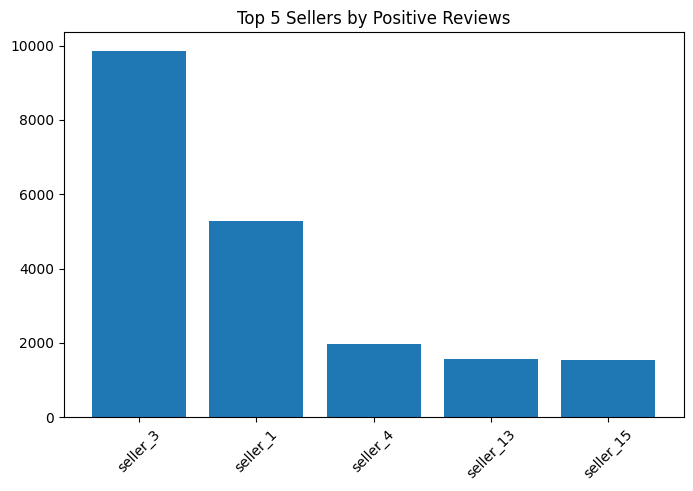

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    seller_positive['seller_id'],
    seller_positive['Positive Reviews']
)

plt.title('Top 5 Sellers by Positive Reviews')
plt.xticks(rotation=45)

plt.show()

Large sellers naturally get more positive reviews. so we also see Positive Sentiment Rate

In [ ]:
seller_sentiment_rate = (
    df.groupby('seller_id')['sentiment_label']
    .apply(lambda x: (x=='Positive').mean()*100)
    .reset_index(name='Positive Rate')
)

seller_sentiment_rate = seller_sentiment_rate.sort_values(
    by='Positive Rate',
    ascending=False
).head(5)

print(seller_sentiment_rate)

    seller_id  Positive Rate
2   seller_11      88.888889
4   seller_13      88.547009
5   seller_14      88.099467
12  seller_20      87.586207
6   seller_15      87.322342


#Top 5 Sellers With Highest Negative Sentiment

In [ ]:
seller_negative = (
    df[df['sentiment_label'] == 'Negative']
    .groupby('seller_id')
    .size()
    .reset_index(name='Negative Reviews')
)

seller_negative = seller_negative.sort_values(
    by='Negative Reviews',
    ascending=False
).head(5)

print(seller_negative)

    seller_id  Negative Reviews
14   seller_3              1374
0    seller_1               529
15   seller_4               233
6   seller_15               112
4   seller_13               105


#Top Positive Keywords

In [ ]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [ ]:
df['clean_review'] = df['review_body_clean'].apply(clean_text)

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
positive_reviews = " ".join(
    df[df['sentiment_label']=='Positive']['clean_review']
)

In [ ]:
#Tokenization
words = positive_reviews.split()

filtered_words = [
    word
    for word in words
    if word not in stop_words
]

In [ ]:
#Word Frequency
from collections import Counter

positive_word_freq = Counter(filtered_words)

top_positive_words = positive_word_freq.most_common(20)

print(top_positive_words)

[('love', 10518), ('kindle', 8208), ('fire', 6894), ('great', 6667), ('use', 4376), ('tablet', 4023), ('one', 3997), ('hd', 3481), ('like', 3438), ('easy', 2911), ('good', 2480), ('would', 2292), ('new', 2277), ('much', 2204), ('amazon', 2186), ('books', 2162), ('really', 2017), ('screen', 1897), ('im', 1818), ('get', 1803)]


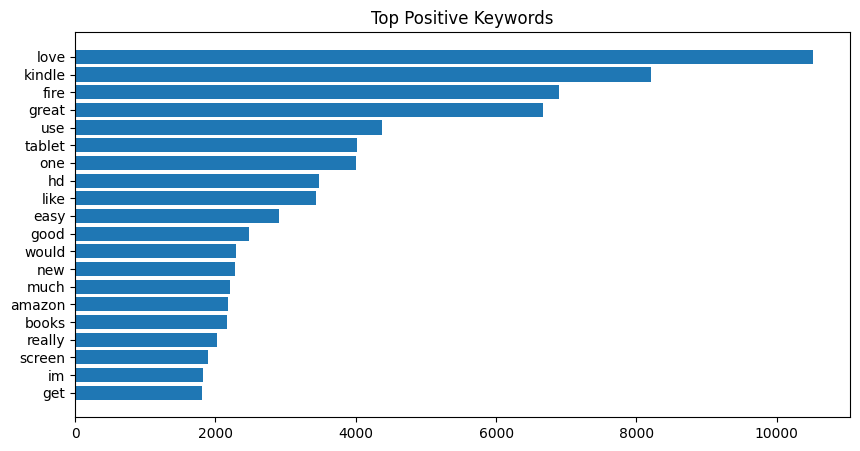

In [ ]:
positive_df = pd.DataFrame(
    top_positive_words,
    columns=['Word','Count']
)

plt.figure(figsize=(10,5))

plt.barh(
    positive_df['Word'],
    positive_df['Count']
)
plt.gca().invert_yaxis()
plt.title('Top Positive Keywords')

plt.show()

#Top Negative Keywords

In [ ]:
negative_reviews = " ".join(
    df[df['sentiment_label']=='Negative']['clean_review']
)

words = negative_reviews.split()

filtered_words = [
    word
    for word in words
    if word not in stop_words
]

negative_word_freq = Counter(filtered_words)

top_negative_words = negative_word_freq.most_common(20)

print(top_negative_words)

[('kindle', 1856), ('amazon', 1394), ('fire', 1179), ('one', 1138), ('tablet', 846), ('would', 846), ('get', 781), ('device', 776), ('apps', 736), ('use', 734), ('like', 613), ('time', 561), ('screen', 549), ('hd', 529), ('dont', 525), ('even', 510), ('new', 497), ('back', 495), ('bought', 466), ('im', 454)]


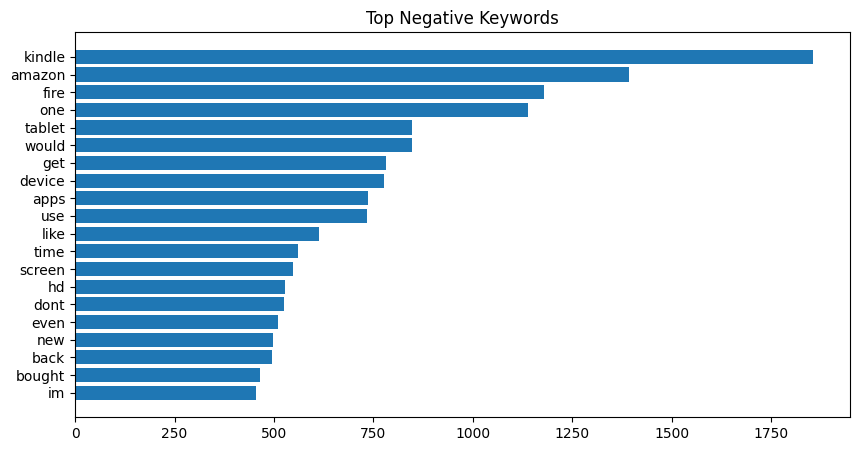

In [ ]:
negative_df = pd.DataFrame(
    top_negative_words,
    columns=['Word','Count']
)

plt.figure(figsize=(10,5))

plt.barh(
    negative_df['Word'],
    negative_df['Count']
)
plt.gca().invert_yaxis()
plt.title('Top Negative Keywords')

plt.show()

#Positive and Negative keywords analysis

kindle, fire, tablet, amazon those are product names, not sentiment drivers so we exclude them

In [ ]:
positive_keywords = [
    'love',
    'great',
    'easy',
    'good',
    'books'
]

negative_keywords = [
    'device',
    'apps',
    'screen',
    'dont',
    'back'
]

In [ ]:
from collections import Counter

# Positive Reviews
positive_text = " ".join(
    df[df['sentiment_label'] == 'Positive']['clean_review']
)

positive_counter = Counter(positive_text.split())

# Negative Reviews
negative_text = " ".join(
    df[df['sentiment_label'] == 'Negative']['clean_review']
)

negative_counter = Counter(negative_text.split())

In [ ]:
validation_df = pd.DataFrame({
    'Keyword': positive_keywords + negative_keywords
})

validation_df['Positive Count'] = validation_df['Keyword'].apply(
    lambda x: positive_counter.get(x, 0)
)

validation_df['Negative Count'] = validation_df['Keyword'].apply(
    lambda x: negative_counter.get(x, 0)
)

validation_df

,Keyword,Positive Count,Negative Count
0,love,10518,186
1,great,6667,258
2,easy,2911,93
3,good,2480,369
4,books,2162,298
5,device,1604,776
6,apps,1727,736
7,screen,1897,549
8,dont,1080,525
9,back,605,495


In [ ]:
comparison = validation_df.sort_values(
    by='Negative Count',
    ascending=False
)

comparison

,Keyword,Positive Count,Negative Count
5,device,1604,776
6,apps,1727,736
7,screen,1897,549
8,dont,1080,525
9,back,605,495
3,good,2480,369
4,books,2162,298
1,great,6667,258
0,love,10518,186
2,easy,2911,93


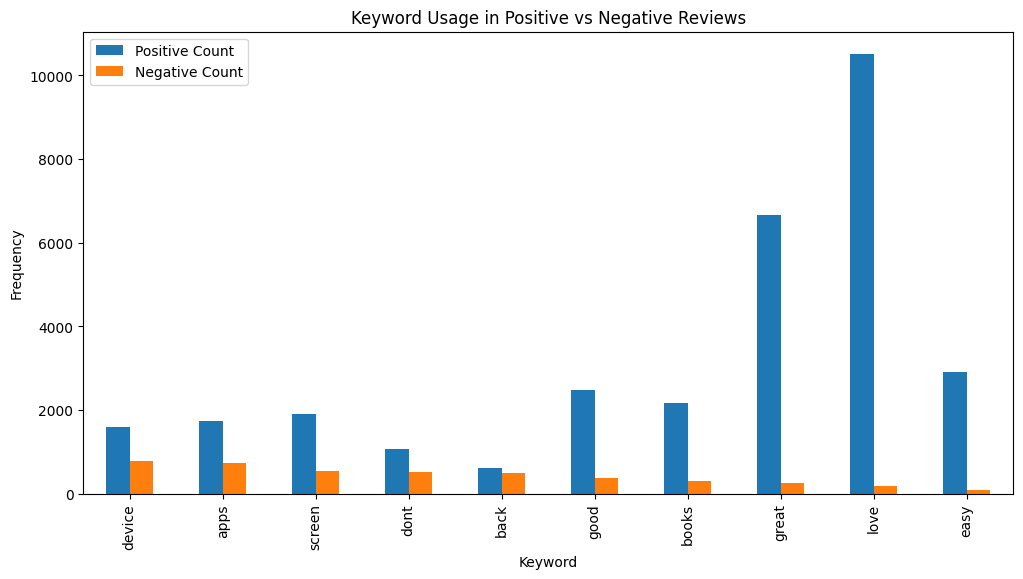

In [ ]:
comparison.set_index('Keyword')[
    ['Positive Count','Negative Count']
].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Keyword Usage in Positive vs Negative Reviews')
plt.ylabel('Frequency')

plt.show()

Keyword analysis shows that customer satisfaction and ease of use are the primary drivers of positive sentiment, with words such as **'love', 'great'**, and **'easy'** appearing most frequently. Product features including the **device, apps,** and **screen** are commonly discussed in both positive and negative reviews, indicating that these features significantly influence the overall customer experience

##Insights

1. Customer sentiment is highly positive, with 83.54% of reviews classified as positive, indicating strong overall customer satisfaction.
2. Five-star ratings dominate customer feedback, accounting for 20,017 reviews and reflecting a consistently positive product experience.
3. Seller_3 is the most influential seller, generating the highest review volume (39% of all reviews) and significantly impacting overall customer sentiment.
4. Seller_3 is a key concern area, contributing the highest number of negative reviews (1,374), making it a priority for performance monitoring and improvement.
5. Seller_13 demonstrates the strongest customer satisfaction performance, combining a high average rating (4.52) with relatively low negative feedback.
6. Negative sentiment is limited to only 9.28% of reviews, suggesting that customer complaints are relatively low across the platform.
7. Keyword analysis indicates that product usability and overall experience drive positive sentiment, while **device functionality, apps, and screen-related issues** are common themes in negative reviews.

---

Analysis of 30,839 customer reviews reveals strong customer satisfaction, with 83.54% of reviews classified as positive and an average rating of 4.33. Five-star ratings dominate customer feedback, highlighting a consistently positive user experience. Seller_3 plays a critical role in overall performance due to its large review volume but also generates the highest number of negative reviews, making it an important area for improvement. In contrast, Seller_13 demonstrates the strongest customer satisfaction performance. Overall, customers are highly satisfied with the products, while negative feedback is primarily associated with device functionality and usability-related concerns.